## Individual Homework


### Imports


In [159]:
# 1. Imports
import gzip
import os
import random
import shutil
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.nn import APPNP, GATConv, GATv2Conv, GCN2Conv, GCNConv, JumpingKnowledge, SAGEConv, SGConv
from torch_geometric.utils import from_networkx, to_undirected


### Graph Loading


In [160]:
os.makedirs("data", exist_ok=True)

urls = {
    "edges": "https://snap.stanford.edu/data/email-Eu-core.txt.gz",
    "labels": "https://snap.stanford.edu/data/email-Eu-core-department-labels.txt.gz",
}

for name, url in urls.items():
    gz_path = f"data/{name}.gz"
    txt_path = f"data/{name}.txt"

    if not os.path.exists(txt_path):
        urllib.request.urlretrieve(url, gz_path)
        with gzip.open(gz_path, "rb") as f_in, open(txt_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)


In [161]:
edges = pd.read_csv(
    "data/edges.txt",
    sep=" ",
    header=None,
    names=["source", "target"],
)
labels = pd.read_csv(
    "data/labels.txt",
    sep=" ",
    header=None,
    names=["node", "department"],
)

print(edges.head())
print(labels.head())

print("Nodes:", labels["node"].nunique())
print("Edges:", len(edges))
print("Classes:", labels["department"].nunique())


   source  target
0       0       1
1       2       3
2       2       4
3       5       6
4       5       7
   node  department
0     0           1
1     1           1
2     2          21
3     3          21
4     4          21
Nodes: 1005
Edges: 25571
Classes: 42


### Graph Building And Calculating Statistics


In [162]:
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.DiGraph(),
)

self_loop_edges = list(nx.selfloop_edges(G))
if self_loop_edges:
    G.remove_edges_from(self_loop_edges)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Removed self-loops:", len(self_loop_edges))
print("Is directed:", G.is_directed())
print("Is weakly connected:", nx.is_weakly_connected(G))
print("Number of weakly connected components:", nx.number_weakly_connected_components(G))
print("Number of strongly connected components:", nx.number_strongly_connected_components(G))

largest_cc = max(nx.weakly_connected_components(G), key=len)
subG = G.subgraph(list(largest_cc)).to_undirected()
subG.remove_edges_from(nx.selfloop_edges(subG))
centrality = nx.degree_centrality(G)

print("Largest component size:", len(largest_cc))
print("Approx diameter:", nx.diameter(subG))
print(
    "Top 5 nodes by centrality:",
    sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5],
)


Number of nodes: 1005
Number of edges: 24929
Removed self-loops: 642
Is directed: True
Is weakly connected: False
Number of weakly connected components: 20
Number of strongly connected components: 203
Largest component size: 986
Approx diameter: 7
Top 5 nodes by centrality: [(160, 0.5418326693227091), (121, 0.3754980079681275), (107, 0.3695219123505976), (62, 0.3655378486055777), (86, 0.35258964143426297)]


In [163]:
degrees = dict(G.degree())
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print("Average degree:", sum(degrees.values()) / len(degrees))
print("Average in-degree:", sum(in_degrees.values()) / len(in_degrees))
print("Average out-degree:", sum(out_degrees.values()) / len(out_degrees))

G_undirected = G.to_undirected()
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

print("Average clustering coefficient:", nx.average_clustering(G_undirected))
print("Density:", nx.density(G))


Average degree: 49.60995024875622
Average in-degree: 24.80497512437811
Average out-degree: 24.80497512437811
Average clustering coefficient: 0.3993549664221539
Density: 0.024706150522288955


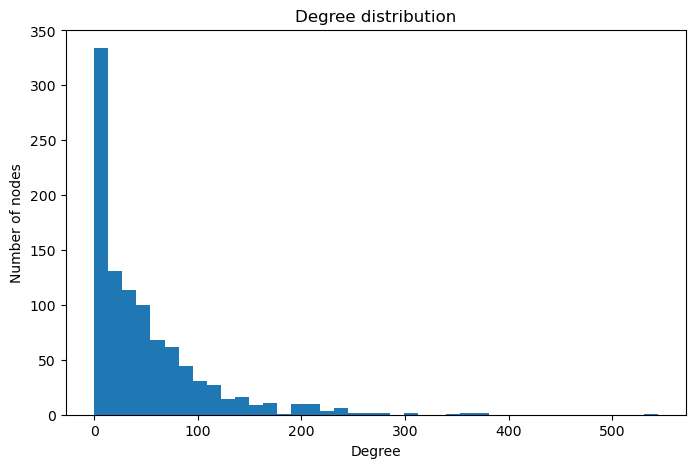

In [164]:
degree_values = list(degrees.values())

plt.figure(figsize=(8, 5))
plt.hist(degree_values, bins=40)
plt.title("Degree distribution")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.show()


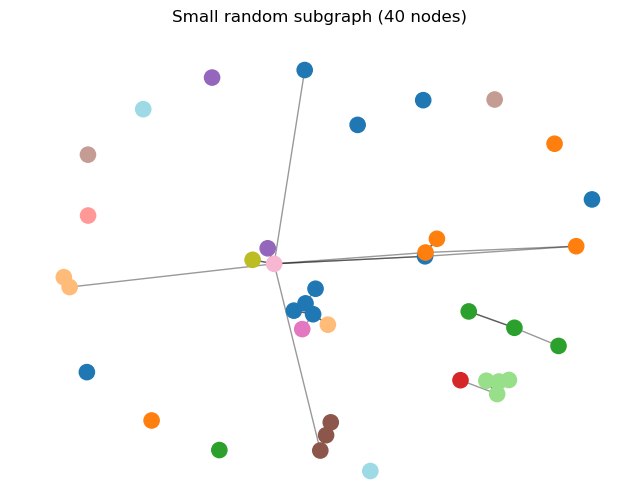

In [165]:
sample_nodes = random.sample(list(G.nodes()), 40)
subG = G.subgraph(sample_nodes).copy()

node_to_label = dict(zip(labels["node"], labels["department"]))
sub_node_colors = [node_to_label.get(node, -1) for node in subG.nodes()]

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subG, seed=42)

nx.draw_networkx_nodes(
    subG,
    pos,
    node_size=120,
    node_color=sub_node_colors,
    cmap=plt.cm.tab20,
)
nx.draw_networkx_edges(subG, pos, alpha=0.4, arrows=False)

plt.title("Small random subgraph (40 nodes)")
plt.axis("off")
plt.show()


In [166]:
all_nodes = sorted(labels["node"].unique())
node_id_to_idx = {node_id: idx for idx, node_id in enumerate(all_nodes)}

edge_pairs = [
    [node_id_to_idx[src], node_id_to_idx[dst]]
    for src, dst in edges.values
    if src != dst
]

edge_index_directed = torch.tensor(edge_pairs, dtype=torch.long).t().contiguous()

# For department classification, communication in either direction is useful signal.
# Keep G directed for feature engineering, but use undirected edges for GNN message passing.
edge_index = to_undirected(edge_index_directed, num_nodes=len(all_nodes))

labels_sorted = labels.sort_values("node")
y = torch.tensor(labels_sorted["department"].values, dtype=torch.long)

print("directed edge_index shape:", edge_index_directed.shape)
print("message-passing edge_index shape:", edge_index.shape)
print("y shape:", y.shape)
print("Number of classes:", y.max().item() + 1)


directed edge_index shape: torch.Size([2, 24929])
message-passing edge_index shape: torch.Size([2, 32128])
y shape: torch.Size([1005])
Number of classes: 42


In [167]:
num_nodes = len(all_nodes)
G.remove_edges_from(nx.selfloop_edges(G))
G_undirected = G.to_undirected()
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

in_deg = torch.zeros(num_nodes, dtype=torch.float)
out_deg = torch.zeros(num_nodes, dtype=torch.float)
reciprocal_deg = torch.zeros(num_nodes, dtype=torch.float)
edge_set = set((src, dst) for src, dst in edges[["source", "target"]].values.tolist() if src != dst)

for src, dst in edges.values:
    if src == dst:
        continue
    src_idx = node_id_to_idx[src]
    dst_idx = node_id_to_idx[dst]
    out_deg[src_idx] += 1
    in_deg[dst_idx] += 1
    if (dst, src) in edge_set:
        reciprocal_deg[src_idx] += 1
        reciprocal_deg[dst_idx] += 1

total_deg = in_deg + out_deg
reciprocity_ratio = reciprocal_deg / (total_deg + 1e-8)
in_ratio = in_deg / (total_deg + 1e-8)
out_ratio = out_deg / (total_deg + 1e-8)

# Reuse the reference repo's graph-statistics idea, adapted from graph-level
# statistics to node-level structural features for this notebook's node task.
degree_centrality = nx.degree_centrality(G_undirected)
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)
clustering = nx.clustering(G_undirected)
triangles = nx.triangles(G_undirected)
core_number = nx.core_number(G_undirected)
avg_neighbor_degree = nx.average_neighbor_degree(G_undirected)
pagerank = nx.pagerank(G_undirected, max_iter=1000)
closeness = nx.closeness_centrality(G_undirected)

try:
    hits_hub, hits_authority = nx.hits(G, max_iter=1000, normalized=True)
except nx.PowerIterationFailedConvergence:
    hits_hub = {node: 0.0 for node in all_nodes}
    hits_authority = {node: 0.0 for node in all_nodes}

try:
    eigenvector = nx.eigenvector_centrality(G_undirected, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eigenvector = {node: 0.0 for node in all_nodes}

# Approximate betweenness keeps the notebook responsive while adding one of the
# centrality signals used in classic graph analysis workflows.
betweenness = nx.betweenness_centrality(
    G_undirected,
    k=min(100, num_nodes),
    seed=42,
    normalized=True,
)

# Node-level analogues of the repo's BFS/component statistics.
hub_node = max(G_undirected.degree(), key=lambda item: item[1])[0]
hub_distance = nx.single_source_shortest_path_length(G_undirected, hub_node)
component_size = {}
for component_nodes in nx.connected_components(G_undirected):
    size = len(component_nodes)
    for node in component_nodes:
        component_size[node] = size

two_hop_neighbors = {}
for node in all_nodes:
    expanded = set(G_undirected.neighbors(node))
    for neighbor in G_undirected.neighbors(node):
        expanded.update(G_undirected.neighbors(neighbor))
    expanded.discard(node)
    two_hop_neighbors[node] = len(expanded)

# Unsupervised community structure is often useful for organization/department graphs.
communities = list(nx.community.greedy_modularity_communities(G_undirected))
node_to_community = {}
for community_id, community_nodes in enumerate(communities):
    for node in community_nodes:
        node_to_community[node] = community_id

community_id = torch.tensor(
    [node_to_community.get(node, -1) for node in all_nodes],
    dtype=torch.long,
)
community_features = torch.nn.functional.one_hot(
    community_id.clamp(min=0),
    num_classes=max(1, len(communities)),
).float()

community_size = {}
community_internal_ratio = {}
community_boundary_ratio = {}
community_neighbor_entropy = {}
for node in all_nodes:
    own_community = node_to_community.get(node, -1)
    neighbors = list(G_undirected.neighbors(node))
    same_community_neighbors = [n for n in neighbors if node_to_community.get(n, -2) == own_community]
    community_size[node] = len(communities[own_community]) if own_community >= 0 else 1
    community_internal_ratio[node] = len(same_community_neighbors) / max(1, len(neighbors))
    community_boundary_ratio[node] = 1.0 - community_internal_ratio[node]

    neighbor_communities = [node_to_community.get(n, -1) for n in neighbors]
    if neighbor_communities:
        counts = np.bincount(neighbor_communities, minlength=max(1, len(communities))).astype(float)
        probs = counts / counts.sum()
        community_neighbor_entropy[node] = float(-(probs[probs > 0] * np.log(probs[probs > 0])).sum() / np.log(max(2, len(communities))))
    else:
        community_neighbor_entropy[node] = 0.0

# Spectral positional encodings capture global graph position without using labels.
spectral_dim = 16
try:
    spectral_adj = torch.zeros((num_nodes, num_nodes), dtype=torch.float)
    spectral_adj[edge_index[0], edge_index[1]] = 1.0
    spectral_adj.fill_diagonal_(1.0)
    spectral_degree = spectral_adj.sum(dim=1).clamp(min=1.0)
    spectral_norm = spectral_adj / torch.sqrt(spectral_degree[:, None] * spectral_degree[None, :])
    _, spectral_vectors = torch.linalg.eigh(spectral_norm)
    spectral_features = spectral_vectors[:, -(spectral_dim + 1):-1]
except Exception as exc:
    print("Spectral features failed; using zeros:", exc)
    spectral_features = torch.zeros((num_nodes, spectral_dim), dtype=torch.float)

spectral_features = torch.nan_to_num(spectral_features, nan=0.0, posinf=0.0, neginf=0.0)
spectral_features = (spectral_features - spectral_features.mean(dim=0)) / (spectral_features.std(dim=0) + 1e-8)

def neighbor_mean(values, node):
    neighbors = list(G_undirected.neighbors(node))
    if not neighbors:
        return 0.0
    return float(np.mean([values[neighbor] for neighbor in neighbors]))


def neighbor_std(values, node):
    neighbors = list(G_undirected.neighbors(node))
    if len(neighbors) <= 1:
        return 0.0
    return float(np.std([values[neighbor] for neighbor in neighbors]))


def neighbor_max(values, node):
    neighbors = list(G_undirected.neighbors(node))
    if not neighbors:
        return 0.0
    return float(np.max([values[neighbor] for neighbor in neighbors]))


def directed_neighbor_mean(values, neighbors):
    neighbors = list(neighbors)
    if not neighbors:
        return 0.0
    return float(np.mean([values[neighbor] for neighbor in neighbors]))

node_total_degree = {node: float(total_deg[node_id_to_idx[node]].item()) for node in all_nodes}
node_in_degree = {node: float(in_deg[node_id_to_idx[node]].item()) for node in all_nodes}
node_out_degree = {node: float(out_deg[node_id_to_idx[node]].item()) for node in all_nodes}

feature_columns = {
    "log_in_degree": torch.log1p(in_deg),
    "log_out_degree": torch.log1p(out_deg),
    "log_total_degree": torch.log1p(total_deg),
    "in_ratio": in_ratio,
    "out_ratio": out_ratio,
    "reciprocity_ratio": reciprocity_ratio,
    "log_degree_product": torch.log1p(in_deg * out_deg),
    "abs_in_out_diff": torch.abs(in_deg - out_deg),
    "signed_in_out_balance": (in_deg - out_deg) / (total_deg + 1e-8),
    "degree_centrality": torch.tensor([degree_centrality[node] for node in all_nodes], dtype=torch.float),
    "in_degree_centrality": torch.tensor([in_degree_centrality[node] for node in all_nodes], dtype=torch.float),
    "out_degree_centrality": torch.tensor([out_degree_centrality[node] for node in all_nodes], dtype=torch.float),
    "clustering": torch.tensor([clustering[node] for node in all_nodes], dtype=torch.float),
    "log_triangles": torch.log1p(torch.tensor([triangles[node] for node in all_nodes], dtype=torch.float)),
    "core_number": torch.tensor([core_number[node] for node in all_nodes], dtype=torch.float),
    "avg_neighbor_degree": torch.tensor([avg_neighbor_degree[node] for node in all_nodes], dtype=torch.float),
    "pagerank": torch.tensor([pagerank[node] for node in all_nodes], dtype=torch.float),
    "closeness": torch.tensor([closeness[node] for node in all_nodes], dtype=torch.float),
    "hits_hub": torch.tensor([hits_hub[node] for node in all_nodes], dtype=torch.float),
    "hits_authority": torch.tensor([hits_authority[node] for node in all_nodes], dtype=torch.float),
    "eigenvector": torch.tensor([eigenvector[node] for node in all_nodes], dtype=torch.float),
    "betweenness_approx": torch.tensor([betweenness[node] for node in all_nodes], dtype=torch.float),
    "hub_distance": torch.tensor([hub_distance.get(node, num_nodes) for node in all_nodes], dtype=torch.float),
    "component_size": torch.log1p(torch.tensor([component_size.get(node, 1) for node in all_nodes], dtype=torch.float)),
    "log_two_hop_neighbors": torch.log1p(torch.tensor([two_hop_neighbors[node] for node in all_nodes], dtype=torch.float)),
    "log_community_size": torch.log1p(torch.tensor([community_size[node] for node in all_nodes], dtype=torch.float)),
    "community_internal_ratio": torch.tensor([community_internal_ratio[node] for node in all_nodes], dtype=torch.float),
    "community_boundary_ratio": torch.tensor([community_boundary_ratio[node] for node in all_nodes], dtype=torch.float),
    "community_neighbor_entropy": torch.tensor([community_neighbor_entropy[node] for node in all_nodes], dtype=torch.float),
    "neighbor_mean_total_degree": torch.tensor([neighbor_mean(node_total_degree, node) for node in all_nodes], dtype=torch.float),
    "neighbor_std_total_degree": torch.tensor([neighbor_std(node_total_degree, node) for node in all_nodes], dtype=torch.float),
    "neighbor_max_total_degree": torch.tensor([neighbor_max(node_total_degree, node) for node in all_nodes], dtype=torch.float),
    "neighbor_mean_pagerank": torch.tensor([neighbor_mean(pagerank, node) for node in all_nodes], dtype=torch.float),
    "neighbor_mean_clustering": torch.tensor([neighbor_mean(clustering, node) for node in all_nodes], dtype=torch.float),
    "predecessor_mean_out_degree": torch.tensor([directed_neighbor_mean(node_out_degree, G.predecessors(node)) for node in all_nodes], dtype=torch.float),
    "successor_mean_in_degree": torch.tensor([directed_neighbor_mean(node_in_degree, G.successors(node)) for node in all_nodes], dtype=torch.float),
}

structural_feature_names = list(feature_columns.keys())
structural_x = torch.stack(list(feature_columns.values()), dim=1)
structural_x = torch.nan_to_num(structural_x, nan=0.0, posinf=0.0, neginf=0.0)
structural_x = (structural_x - structural_x.mean(dim=0)) / (structural_x.std(dim=0) + 1e-8)

# Community one-hot features are already scaled binary indicators.
x = torch.cat([structural_x, community_features, spectral_features], dim=1)
feature_names = (
    structural_feature_names
    + [f"community_{i}" for i in range(community_features.size(1))]
    + [f"spectral_pos_{i}" for i in range(spectral_features.size(1))]
)

print("Structural feature count:", len(structural_feature_names))
print("Detected communities:", len(communities))
print("Spectral feature count:", spectral_features.size(1))
print("x shape:", x.shape)
print("First feature names:", feature_names[:10])


Structural feature count: 36
Detected communities: 27
Spectral feature count: 16
x shape: torch.Size([1005, 79])
First feature names: ['log_in_degree', 'log_out_degree', 'log_total_degree', 'in_ratio', 'out_ratio', 'reciprocity_ratio', 'log_degree_product', 'abs_in_out_diff', 'signed_in_out_balance', 'degree_centrality']


In [168]:
class_counts = Counter(y.numpy())
valid_classes = sorted(cls for cls, count in class_counts.items() if count >= 5)
class_to_idx = {cls: idx for idx, cls in enumerate(valid_classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

y_mapped = torch.full_like(y, fill_value=-1)
for original_class, mapped_class in class_to_idx.items():
    y_mapped[y == original_class] = mapped_class

valid_node_mask = y_mapped >= 0
valid_indices = valid_node_mask.nonzero(as_tuple=True)[0]

print("Original nodes:", len(y))
print("Remaining nodes:", len(valid_indices))
print("Original classes:", len(class_counts))
print("Remaining classes:", len(valid_classes))


Original nodes: 1005
Remaining nodes: 987
Original classes: 42
Remaining classes: 35


In [169]:
train_idx, temp_idx = train_test_split(
    valid_indices.numpy(),
    test_size=0.4,
    random_state=42,
    stratify=y_mapped[valid_indices].numpy(),
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=y_mapped[temp_idx].numpy(),
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data = Data(
    x=x,
    edge_index=edge_index,
    y=y_mapped,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

print(data)
print("Train nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())


Data(x=[1005, 79], edge_index=[2, 32128], y=[1005], train_mask=[1005], val_mask=[1005], test_mask=[1005])
Train nodes: 592
Validation nodes: 197
Test nodes: 198


### Train-Label Propagation Features


In [170]:
label_feature_classes = int(data.y.max().item()) + 1
label_seed = torch.zeros((num_nodes, label_feature_classes), dtype=torch.float)
label_seed[data.train_mask] = torch.nn.functional.one_hot(
    data.y[data.train_mask],
    num_classes=label_feature_classes,
).float()

adj_binary = torch.zeros((num_nodes, num_nodes), dtype=torch.float)
adj_binary[data.edge_index[0], data.edge_index[1]] = 1.0
adj_no_self = adj_binary.clone()
adj_no_self.fill_diagonal_(0.0)

adj = adj_no_self.clone()
adj.fill_diagonal_(1.0)
adj = adj / adj.sum(dim=1, keepdim=True).clamp(min=1.0)
adj_neighbors = adj_no_self / adj_no_self.sum(dim=1, keepdim=True).clamp(min=1.0)

train_indicator = data.train_mask.float().view(-1, 1)
one_hop_train_coverage = adj_neighbors @ train_indicator
one_hop_label_dist = adj_neighbors @ label_seed

two_hop_reach = (adj_no_self @ adj_no_self > 0).float()
two_hop_reach.fill_diagonal_(0.0)
two_hop_norm = two_hop_reach / two_hop_reach.sum(dim=1, keepdim=True).clamp(min=1.0)
two_hop_train_coverage = two_hop_norm @ train_indicator
two_hop_label_dist = two_hop_norm @ label_seed

label_feature_blocks = [
    one_hop_label_dist,
    one_hop_train_coverage,
    two_hop_label_dist,
    two_hop_train_coverage,
]
label_feature_names = (
    [f"train_label_1hop_{i}" for i in range(label_feature_classes)]
    + ["train_label_1hop_coverage"]
    + [f"train_label_2hop_{i}" for i in range(label_feature_classes)]
    + ["train_label_2hop_coverage"]
)

for steps, alpha in [(2, 0.50), (4, 0.80), (8, 0.95)]:
    label_signal = label_seed.clone()
    for _ in range(steps):
        label_signal = alpha * adj @ label_signal + (1 - alpha) * label_seed
        label_signal[data.train_mask] = label_seed[data.train_mask]

    label_confidence = label_signal.max(dim=1, keepdim=True).values
    label_entropy = -(
        label_signal.clamp(min=1e-12) * label_signal.clamp(min=1e-12).log()
    ).sum(dim=1, keepdim=True)
    label_entropy = label_entropy / np.log(label_feature_classes)

    label_feature_blocks.extend([label_signal, label_confidence, label_entropy])
    suffix = f"steps{steps}_alpha{str(alpha).replace('.', '')}"
    label_feature_names.extend([f"train_label_prop_{suffix}_{i}" for i in range(label_feature_classes)])
    label_feature_names.extend([
        f"train_label_prop_{suffix}_confidence",
        f"train_label_prop_{suffix}_entropy",
    ])

label_propagation_features = torch.cat(label_feature_blocks, dim=1)
label_propagation_features = torch.nan_to_num(label_propagation_features, nan=0.0, posinf=0.0, neginf=0.0)

data.x = torch.cat([data.x, label_propagation_features], dim=1)
feature_names = feature_names + label_feature_names

print("Train-label feature count:", label_propagation_features.size(1))
print("Updated x shape:", data.x.shape)


Train-label feature count: 183
Updated x shape: torch.Size([1005, 262])


### Optional Node2Vec Embeddings


In [171]:
use_node2vec = True
node2vec_dim = 64
node2vec_epochs = 50

# Make this cell safe to rerun without repeatedly appending the same embeddings.
if "x_before_node2vec" not in globals():
    x_before_node2vec = data.x.clone()
    feature_names_before_node2vec = list(feature_names)
else:
    data.x = x_before_node2vec.clone()
    feature_names = list(feature_names_before_node2vec)

if use_node2vec:
    try:
        from torch_geometric.nn import Node2Vec as PyGNode2Vec

        node2vec_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        node2vec_model = PyGNode2Vec(
            data.edge_index,
            embedding_dim=node2vec_dim,
            walk_length=20,
            context_size=10,
            walks_per_node=10,
            num_negative_samples=1,
            p=1.0,
            q=1.0,
            sparse=True,
        ).to(node2vec_device)

        node2vec_loader = node2vec_model.loader(batch_size=128, shuffle=True)
        node2vec_optimizer = torch.optim.SparseAdam(list(node2vec_model.parameters()), lr=0.01)
        node2vec_model.train()

        for epoch in range(1, node2vec_epochs + 1):
            total_loss = 0.0
            for pos_rw, neg_rw in node2vec_loader:
                node2vec_optimizer.zero_grad()
                loss = node2vec_model.loss(pos_rw.to(node2vec_device), neg_rw.to(node2vec_device))
                loss.backward()
                node2vec_optimizer.step()
                total_loss += float(loss.item())
            if epoch in {1, node2vec_epochs} or epoch % 10 == 0:
                print(f"Node2Vec epoch {epoch:03d} | loss={total_loss / max(1, len(node2vec_loader)):.4f}")

        node2vec_model.eval()
        with torch.no_grad():
            node2vec_features = node2vec_model.embedding.weight.detach().cpu()
        node2vec_features = (node2vec_features - node2vec_features.mean(dim=0)) / (node2vec_features.std(dim=0) + 1e-8)
        data.x = torch.cat([data.x, node2vec_features], dim=1)
        feature_names = feature_names + [f"node2vec_{i}" for i in range(node2vec_features.size(1))]
        print("Node2Vec features added:", node2vec_features.shape)
    except Exception as exc:
        print("Node2Vec skipped because required backend is unavailable or training failed:", repr(exc))
else:
    print("Node2Vec disabled")

print("x shape after optional Node2Vec:", data.x.shape)


Node2Vec skipped because required backend is unavailable or training failed: ImportError("'Node2Vec' requires either the 'pyg-lib' or 'torch-cluster' package")
x shape after optional Node2Vec: torch.Size([1005, 262])


### Model Training And Evaluation


In [172]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_features = data.num_node_features
num_classes = int(data.y.max().item()) + 1

train_class_counts = torch.bincount(
    data.y[data.train_mask],
    minlength=num_classes,
).float()
full_class_weights = train_class_counts.sum() / (num_classes * train_class_counts.clamp(min=1.0))
full_class_weights = full_class_weights / full_class_weights.mean()
sqrt_class_weights = 1.0 / torch.sqrt(train_class_counts.clamp(min=1.0))
sqrt_class_weights = sqrt_class_weights / sqrt_class_weights.mean()

print("Device:", device)
print("Number of features:", num_features)
print("Number of classes:", num_classes)
print("Sqrt class weights:", torch.round(sqrt_class_weights * 1000) / 1000)


Device: cpu
Number of features: 262
Number of classes: 35
Sqrt class weights: tensor([0.6090, 0.5250, 1.3390, 1.2400, 0.4070, 0.9890, 0.7950, 0.5890, 0.9890,
        0.7520, 0.6840, 0.7950, 0.8200, 0.4420, 0.5710, 0.8470, 0.7160, 0.7950,
        1.1590, 0.5390, 0.8470, 0.8200, 1.6400, 1.6400, 1.4670, 1.3390, 1.4670,
        1.8930, 1.4670, 1.3390, 1.1590, 1.1590, 0.9100, 1.0930, 1.1590])


In [173]:
class GNN(torch.nn.Module):
    def __init__(
        self,
        model_name,
        in_channels,
        hidden_channels,
        out_channels,
        dropout=0.5,
        heads=4,
        num_layers=2,
        use_batch_norm=False,
        residual=False,
        appnp_k=10,
        appnp_alpha=0.1,
        sgc_k=2,
    ):
        super().__init__()
        self.model_name = model_name
        self.dropout = dropout
        self.residual = residual
        self.use_batch_norm = use_batch_norm

        if model_name == "APPNP":
            layers = [torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU(), torch.nn.Dropout(dropout)]
            for _ in range(max(0, num_layers - 2)):
                layers += [torch.nn.Linear(hidden_channels, hidden_channels), torch.nn.ReLU(), torch.nn.Dropout(dropout)]
            layers.append(torch.nn.Linear(hidden_channels, out_channels))
            self.mlp = torch.nn.Sequential(*layers)
            self.propagation = APPNP(K=appnp_k, alpha=appnp_alpha, dropout=dropout)
            return

        if model_name == "SGC":
            self.sgc = SGConv(in_channels, out_channels, K=sgc_k, cached=False)
            return

        if model_name == "GCNII":
            self.input_proj = torch.nn.Linear(in_channels, hidden_channels)
            self.convs = torch.nn.ModuleList([
                GCN2Conv(hidden_channels, alpha=0.1, theta=0.5, layer=layer + 1)
                for layer in range(num_layers)
            ])
            self.norms = torch.nn.ModuleList([torch.nn.BatchNorm1d(hidden_channels) for _ in range(num_layers)])
            self.output_proj = torch.nn.Linear(hidden_channels, out_channels)
            return

        if model_name == "JKGraphSAGE":
            self.convs = torch.nn.ModuleList()
            self.norms = torch.nn.ModuleList()
            self.convs.append(SAGEConv(in_channels, hidden_channels))
            self.norms.append(torch.nn.BatchNorm1d(hidden_channels))
            for _ in range(num_layers - 1):
                self.convs.append(SAGEConv(hidden_channels, hidden_channels))
                self.norms.append(torch.nn.BatchNorm1d(hidden_channels))
            self.jk = JumpingKnowledge(mode="cat")
            self.output_proj = torch.nn.Linear(hidden_channels * num_layers, out_channels)
            return

        self.convs = torch.nn.ModuleList()
        self.norms = torch.nn.ModuleList()
        self.residual_projections = torch.nn.ModuleList()

        if model_name in {"GAT", "GATv2"}:
            conv_cls = GATConv if model_name == "GAT" else GATv2Conv
            hidden_dim = hidden_channels * heads
            self.convs.append(conv_cls(in_channels, hidden_channels, heads=heads, dropout=dropout))
            self.norms.append(torch.nn.BatchNorm1d(hidden_dim))
            self.residual_projections.append(torch.nn.Linear(in_channels, hidden_dim))
            for _ in range(num_layers - 2):
                self.convs.append(conv_cls(hidden_dim, hidden_channels, heads=heads, dropout=dropout))
                self.norms.append(torch.nn.BatchNorm1d(hidden_dim))
                self.residual_projections.append(torch.nn.Identity())
            self.out_conv = conv_cls(hidden_dim, out_channels, heads=1, concat=False, dropout=dropout)
            return

        conv_cls = {"GCN": GCNConv, "GraphSAGE": SAGEConv}.get(model_name)
        if conv_cls is None:
            raise ValueError(f"Unknown model: {model_name}")

        self.convs.append(conv_cls(in_channels, hidden_channels))
        self.norms.append(torch.nn.BatchNorm1d(hidden_channels))
        self.residual_projections.append(torch.nn.Linear(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(conv_cls(hidden_channels, hidden_channels))
            self.norms.append(torch.nn.BatchNorm1d(hidden_channels))
            self.residual_projections.append(torch.nn.Identity())
        self.out_conv = conv_cls(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        if self.model_name == "APPNP":
            x = self.mlp(x)
            return self.propagation(x, edge_index)

        if self.model_name == "SGC":
            return self.sgc(x, edge_index)

        if self.model_name == "GCNII":
            x = torch.relu(self.input_proj(x))
            x0 = x
            for conv, norm in zip(self.convs, self.norms):
                x = torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
                x = conv(x, x0, edge_index)
                if self.use_batch_norm:
                    x = norm(x)
                x = torch.relu(x)
            x = torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
            return self.output_proj(x)

        if self.model_name == "JKGraphSAGE":
            outputs = []
            for conv, norm in zip(self.convs, self.norms):
                x = conv(x, edge_index)
                if self.use_batch_norm:
                    x = norm(x)
                x = torch.relu(x)
                x = torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
                outputs.append(x)
            return self.output_proj(self.jk(outputs))

        for conv, norm, projection in zip(self.convs, self.norms, self.residual_projections):
            previous = x
            x = conv(x, edge_index)
            if self.use_batch_norm:
                x = norm(x)
            x = torch.relu(x)
            x = torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
            if self.residual:
                x = x + projection(previous)
        return self.out_conv(x, edge_index)


In [174]:
def prediction_scores(y_true, y_pred, prefix):
    return {
        f"{prefix}_accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        f"{prefix}_f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def evaluate_predictions(pred, graph_data):
    scores = {}
    for split_name, mask in {
        "train": graph_data.train_mask,
        "val": graph_data.val_mask,
        "test": graph_data.test_mask,
    }.items():
        y_true = graph_data.y[mask].detach().cpu().numpy()
        y_pred = pred[mask].detach().cpu().numpy()
        scores.update(prediction_scores(y_true, y_pred, split_name))
    return scores


def evaluate_model(model, graph_data):
    model.eval()
    with torch.no_grad():
        logits = model(graph_data.x, graph_data.edge_index)
        pred = logits.argmax(dim=1)
    return evaluate_predictions(pred.detach().cpu(), graph_data.cpu()), pred.detach().cpu(), logits.detach().cpu()


def train_model(
    model_name,
    hidden_channels=32,
    lr=0.01,
    weight_decay=5e-4,
    dropout=0.5,
    heads=4,
    num_layers=2,
    use_batch_norm=True,
    residual=True,
    loss_weight_mode="none",
    epochs=180,
    patience=35,
    seed=42,
    **kwargs,
):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    graph_data = data.clone().to(device)
    model = GNN(
        model_name=model_name,
        in_channels=num_features,
        hidden_channels=hidden_channels,
        out_channels=num_classes,
        dropout=dropout,
        heads=heads,
        num_layers=num_layers,
        use_batch_norm=use_batch_norm,
        residual=residual,
        appnp_k=kwargs.get("appnp_k", 10),
        appnp_alpha=kwargs.get("appnp_alpha", 0.1),
        sgc_k=kwargs.get("sgc_k", 2),
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )
    if loss_weight_mode == "sqrt":
        loss_weights = sqrt_class_weights.to(device)
    elif loss_weight_mode == "full":
        loss_weights = full_class_weights.to(device)
    else:
        loss_weights = None

    best_state = None
    best_val_loss = float("inf")
    best_epoch = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(graph_data.x, graph_data.edge_index)
        loss = torch.nn.functional.cross_entropy(
            logits[graph_data.train_mask],
            graph_data.y[graph_data.train_mask],
            weight=loss_weights,
        )
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(graph_data.x, graph_data.edge_index)
            val_loss = torch.nn.functional.cross_entropy(
                val_logits[graph_data.val_mask],
                graph_data.y[graph_data.val_mask],
                weight=loss_weights,
            )
            val_pred = val_logits.argmax(dim=1).detach().cpu()

        scores = evaluate_predictions(val_pred, graph_data.cpu())
        history.append(
            {
                "epoch": epoch,
                "loss": float(loss.item()),
                "val_loss": float(val_loss.item()),
                **scores,
            }
        )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        if epoch - best_epoch >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    final_scores, pred, logits = evaluate_model(model, graph_data)

    return {
        "model": model_name,
        "hidden_channels": hidden_channels,
        "lr": lr,
        "weight_decay": weight_decay,
        "dropout": dropout,
        "heads": heads if model_name == "GAT" else None,
        "num_layers": num_layers,
        "use_batch_norm": use_batch_norm,
        "residual": residual,
        "loss_weight_mode": loss_weight_mode,
        "seed": seed,
        "best_epoch": best_epoch,
        **final_scores,
        "trained_model": model.cpu(),
        "predictions": pred,
        "logits": logits,
        "history": pd.DataFrame(history),
    }


def smooth_probabilities(probabilities, steps=2, alpha=0.8, clamp_train=True):
    smoothed = probabilities.clone()
    train_labels = torch.nn.functional.one_hot(data.y[data.train_mask], num_classes=num_classes).float()

    for _ in range(steps):
        smoothed = alpha * adj @ smoothed + (1 - alpha) * probabilities
        if clamp_train:
            smoothed[data.train_mask] = train_labels

    return smoothed


### Advanced Architecture Comparison


In [176]:
advanced_model_configs = [
    # Control close to the previous best-performing setup.
    {"model_name": "GAT", "hidden_channels": 32, "num_layers": 2, "lr": 0.01, "weight_decay": 5e-4, "dropout": 0.5, "heads": 4, "use_batch_norm": False, "residual": False, "loss_weight_mode": "none"},
    {"model_name": "GAT", "hidden_channels": 32, "num_layers": 2, "lr": 0.01, "weight_decay": 5e-4, "dropout": 0.5, "heads": 4, "use_batch_norm": False, "residual": False, "loss_weight_mode": "sqrt"},

    # Advanced architectures.
    {"model_name": "GATv2", "hidden_channels": 32, "num_layers": 2, "lr": 0.01, "weight_decay": 5e-4, "dropout": 0.5, "heads": 4, "use_batch_norm": False, "residual": False, "loss_weight_mode": "none"},
    {"model_name": "GraphSAGE", "hidden_channels": 64, "num_layers": 3, "lr": 0.005, "weight_decay": 1e-4, "dropout": 0.4, "heads": 1, "use_batch_norm": True, "residual": False, "loss_weight_mode": "none"},
]

seeds = [7, 42, 2024]
results = []
trained_runs = []

for params in advanced_model_configs:
    for seed in seeds:
        run = train_model(
            **params,
            seed=seed,
            epochs=220,
            patience=45,
        )
        run["run_id"] = len(trained_runs)
        trained_runs.append(run)
        results.append(
            {
                key: value
                for key, value in run.items()
                if key not in {"trained_model", "predictions", "logits", "history"}
            }
        )
        print(
            f"{run['model']:11s} seed={seed:4d} | layers={run['num_layers']:2d} "
            f"hidden={run['hidden_channels']:3d} heads={str(run['heads']):>4s} "
            f"weights={run['loss_weight_mode']:>4s} val_acc={run['val_accuracy']:.3f} test_acc={run['test_accuracy']:.3f}"
        )

results_df = pd.DataFrame(results).sort_values(
    by=["val_accuracy", "val_f1_macro", "test_accuracy"],
    ascending=False,
).reset_index(drop=True)

results_df


GAT         seed=   7 | layers= 2 hidden= 32 heads=   4 weights=none val_acc=0.751 test_acc=0.768
GAT         seed=  42 | layers= 2 hidden= 32 heads=   4 weights=none val_acc=0.721 test_acc=0.732
GAT         seed=2024 | layers= 2 hidden= 32 heads=   4 weights=none val_acc=0.751 test_acc=0.773
GAT         seed=   7 | layers= 2 hidden= 32 heads=   4 weights=sqrt val_acc=0.746 test_acc=0.783
GAT         seed=  42 | layers= 2 hidden= 32 heads=   4 weights=sqrt val_acc=0.736 test_acc=0.768
GAT         seed=2024 | layers= 2 hidden= 32 heads=   4 weights=sqrt val_acc=0.772 test_acc=0.793
GATv2       seed=   7 | layers= 2 hidden= 32 heads=None weights=none val_acc=0.731 test_acc=0.753
GATv2       seed=  42 | layers= 2 hidden= 32 heads=None weights=none val_acc=0.736 test_acc=0.747
GATv2       seed=2024 | layers= 2 hidden= 32 heads=None weights=none val_acc=0.751 test_acc=0.778
GraphSAGE   seed=   7 | layers= 3 hidden= 64 heads=None weights=none val_acc=0.721 test_acc=0.702
GraphSAGE   seed=  4

,model,hidden_channels,lr,weight_decay,dropout,heads,num_layers,use_batch_norm,residual,loss_weight_mode,...,train_accuracy,train_f1_macro,train_f1_weighted,val_accuracy,val_f1_macro,val_f1_weighted,test_accuracy,test_f1_macro,test_f1_weighted,run_id
0,GAT,32,0.010,0.0005,0.5,4.0,2,False,False,sqrt,...,0.962838,0.953328,0.963139,0.771574,0.678423,0.769949,0.792929,0.697691,0.774640,5
1,GATv2,32,0.010,0.0005,0.5,NaN,2,False,False,none,...,0.959459,0.936921,0.957937,0.751269,0.590548,0.735321,0.777778,0.627813,0.753995,8
2,GAT,32,0.010,0.0005,0.5,4.0,2,False,False,none,...,0.925676,0.883178,0.920073,0.751269,0.581773,0.736750,0.772727,0.668217,0.750274,2
3,GAT,32,0.010,0.0005,0.5,4.0,2,False,False,none,...,0.932432,0.890657,0.928619,0.751269,0.558742,0.726609,0.767677,0.671362,0.753928,0
4,GAT,32,0.010,0.0005,0.5,4.0,2,False,False,sqrt,...,0.956081,0.943502,0.954921,0.746193,0.608818,0.747333,0.782828,0.696119,0.774195,3
5,GAT,32,0.010,0.0005,0.5,4.0,2,False,False,sqrt,...,0.964527,0.960628,0.964804,0.736041,0.575576,0.730935,0.767677,0.688291,0.767012,4
6,GATv2,32,0.010,0.0005,0.5,NaN,2,False,False,none,...,0.915541,0.844395,0.908269,0.736041,0.539742,0.712397,0.747475,0.596985,0.721918,7
7,GATv2,32,0.010,0.0005,0.5,NaN,2,False,False,none,...,0.929054,0.878226,0.925901,0.730964,0.561174,0.716861,0.752525,0.578476,0.732236,6
8,GraphSAGE,64,0.005,0.0001,0.4,NaN,3,True,False,none,...,1.000000,1.000000,1.000000,0.725888,0.604307,0.725932,0.712121,0.574032,0.707761,11
9,GraphSAGE,64,0.005,0.0001,0.4,NaN,3,True,False,none,...,1.000000,1.000000,1.000000,0.720812,0.604076,0.719721,0.702020,0.594893,0.696126,9


In [177]:
best_config = results_df.iloc[0]
best_run = trained_runs[int(best_config["run_id"])]

print("Best single run selected by validation accuracy + macro F1:")
print(best_config)

summary_columns = [
    "model",
    "seed",
    "num_layers",
    "hidden_channels",
    "lr",
    "weight_decay",
    "dropout",
    "heads",
    "loss_weight_mode",
    "best_epoch",
    "train_accuracy",
    "train_f1_macro",
    "val_accuracy",
    "val_f1_macro",
    "test_accuracy",
    "test_f1_macro",
    "test_f1_weighted",
]

best_by_architecture = results_df.sort_values(
    by=["model", "val_accuracy", "val_f1_macro"],
    ascending=[True, False, False],
).groupby("model", as_index=False).head(1)

best_by_architecture[summary_columns]


Best single run selected by validation accuracy + macro F1:
model                     GAT
hidden_channels            32
lr                       0.01
weight_decay           0.0005
dropout                   0.5
heads                     4.0
num_layers                  2
use_batch_norm          False
residual                False
loss_weight_mode         sqrt
seed                     2024
best_epoch                161
train_accuracy       0.962838
train_f1_macro       0.953328
train_f1_weighted    0.963139
val_accuracy         0.771574
val_f1_macro         0.678423
val_f1_weighted      0.769949
test_accuracy        0.792929
test_f1_macro        0.697691
test_f1_weighted      0.77464
run_id                      5
Name: 0, dtype: object


,model,seed,num_layers,hidden_channels,lr,weight_decay,dropout,heads,loss_weight_mode,best_epoch,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,test_accuracy,test_f1_macro,test_f1_weighted
0,GAT,2024,2,32,0.010,0.0005,0.5,4.0,sqrt,161,0.962838,0.953328,0.771574,0.678423,0.792929,0.697691,0.774640
1,GATv2,2024,2,32,0.010,0.0005,0.5,NaN,none,104,0.959459,0.936921,0.751269,0.590548,0.777778,0.627813,0.753995
8,GraphSAGE,2024,3,64,0.005,0.0001,0.4,NaN,none,111,1.000000,1.000000,0.725888,0.604307,0.712121,0.574032,0.707761


In [178]:
ensemble_candidates = results_df.head(min(6, len(results_df)))
ensemble_logit_list = []
for _, row in ensemble_candidates.iterrows():
    ensemble_logit_list.append(trained_runs[int(row["run_id"])]["logits"])
ensemble_logits = torch.stack(ensemble_logit_list, dim=0).mean(dim=0)
ensemble_probabilities = torch.softmax(ensemble_logits, dim=1)
ensemble_predictions = ensemble_probabilities.argmax(dim=1)
ensemble_scores = evaluate_predictions(ensemble_predictions, data)

smoothing_trials = []
for steps in [1, 2, 4, 8, 16]:
    for alpha in [0.5, 0.7, 0.85, 0.95]:
        smoothed_probabilities = smooth_probabilities(
            ensemble_probabilities,
            steps=steps,
            alpha=alpha,
            clamp_train=True,
        )
        smoothed_predictions = smoothed_probabilities.argmax(dim=1)
        scores = evaluate_predictions(smoothed_predictions, data)
        smoothing_trials.append(
            {
                "steps": steps,
                "alpha": alpha,
                **scores,
                "predictions": smoothed_predictions,
                "probabilities": smoothed_probabilities,
            }
        )

smoothing_results_df = pd.DataFrame(
    [
        {key: value for key, value in row.items() if key not in {"predictions", "probabilities"}}
        for row in smoothing_trials
    ]
).sort_values(
    by=["val_accuracy", "val_f1_macro", "test_accuracy"],
    ascending=False,
).reset_index(drop=True)

best_smoothing = max(
    smoothing_trials,
    key=lambda row: (row["val_accuracy"], row["val_f1_macro"], row["test_accuracy"]),
)

candidate_score_rows = [
    {"method": "best_single", **{k: v for k, v in best_run.items() if k.endswith("accuracy") or k.endswith("f1_macro") or k.endswith("f1_weighted")}},
    {"method": "ensemble_top_val", **ensemble_scores},
    {"method": f"smoothed_ensemble_s{best_smoothing['steps']}_a{best_smoothing['alpha']}", **{k: v for k, v in best_smoothing.items() if k.endswith("accuracy") or k.endswith("f1_macro") or k.endswith("f1_weighted")}},
]
comparison_df = pd.DataFrame(candidate_score_rows).sort_values(
    by=["val_accuracy", "val_f1_macro", "test_accuracy"],
    ascending=False,
).reset_index(drop=True)

display(comparison_df)
display(smoothing_results_df.head(10))

if comparison_df.iloc[0]["method"] == "best_single":
    final_predictions = best_run["predictions"]
    final_probabilities = torch.softmax(best_run["logits"], dim=1)
else:
    final_predictions = best_smoothing["predictions"] if comparison_df.iloc[0]["method"].startswith("smoothed") else ensemble_predictions
    final_probabilities = best_smoothing["probabilities"] if comparison_df.iloc[0]["method"].startswith("smoothed") else ensemble_probabilities

best_run["predictions"] = final_predictions
best_run["final_probabilities"] = final_probabilities
best_run["final_method"] = comparison_df.iloc[0]["method"]

print("Selected final method:", best_run["final_method"])


,method,train_accuracy,train_f1_macro,train_f1_weighted,val_accuracy,val_f1_macro,val_f1_weighted,test_accuracy,test_f1_macro,test_f1_weighted
0,smoothed_ensemble_s2_a0.5,1.000000,1.000000,1.000000,0.781726,0.666715,0.772325,0.772727,0.697820,0.753578
1,best_single,0.962838,0.953328,0.963139,0.771574,0.678423,0.769949,0.792929,0.697691,0.774640
2,ensemble_top_val,0.959459,0.945743,0.957717,0.756345,0.594518,0.744035,0.792929,0.704573,0.779505


,steps,alpha,train_accuracy,train_f1_macro,train_f1_weighted,val_accuracy,val_f1_macro,val_f1_weighted,test_accuracy,test_f1_macro,test_f1_weighted
0,2,0.5,1.0,1.0,1.0,0.781726,0.666715,0.772325,0.772727,0.697820,0.753578
1,4,0.5,1.0,1.0,1.0,0.781726,0.666715,0.772325,0.772727,0.697820,0.753578
2,8,0.5,1.0,1.0,1.0,0.781726,0.666715,0.772325,0.772727,0.697820,0.753578
3,16,0.5,1.0,1.0,1.0,0.781726,0.666715,0.772325,0.772727,0.697820,0.753578
4,2,0.7,1.0,1.0,1.0,0.776650,0.649025,0.762347,0.767677,0.689157,0.745342
5,4,0.7,1.0,1.0,1.0,0.771574,0.644498,0.757511,0.767677,0.689157,0.745342
6,8,0.7,1.0,1.0,1.0,0.771574,0.644498,0.757511,0.767677,0.689157,0.745342
7,16,0.7,1.0,1.0,1.0,0.771574,0.644498,0.757511,0.767677,0.689157,0.745342
8,1,0.5,1.0,1.0,1.0,0.766497,0.614756,0.754223,0.782828,0.705317,0.763766
9,1,0.7,1.0,1.0,1.0,0.761421,0.590225,0.740371,0.772727,0.688207,0.748742


Selected final method: smoothed_ensemble_s2_a0.5


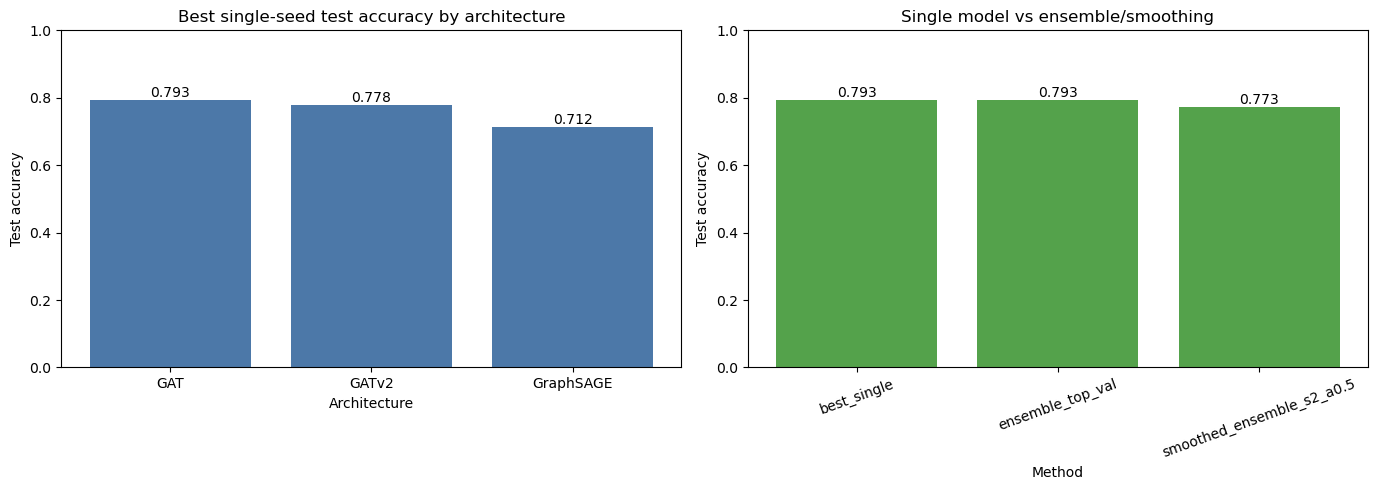

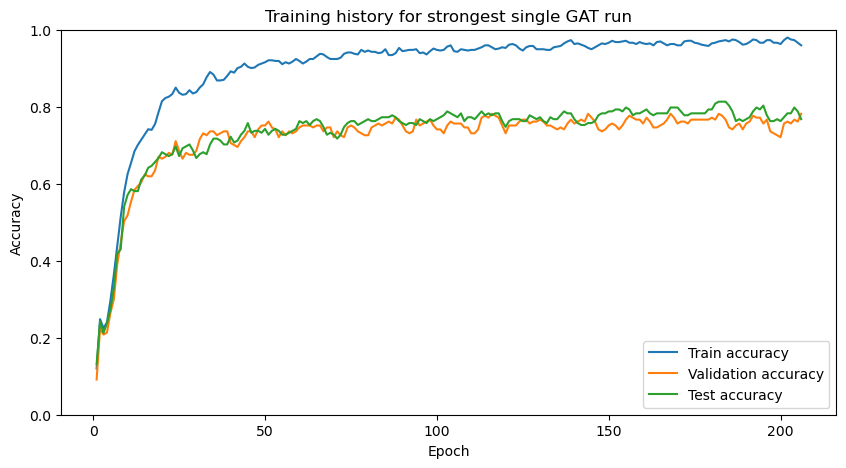

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

arch_plot = best_by_architecture.sort_values("model")
axes[0].bar(arch_plot["model"], arch_plot["test_accuracy"], color="#4c78a8")
axes[0].set_title("Best single-seed test accuracy by architecture")
axes[0].set_xlabel("Architecture")
axes[0].set_ylabel("Test accuracy")
axes[0].set_ylim(0, 1)
for index, row in arch_plot.reset_index(drop=True).iterrows():
    axes[0].text(index, row["test_accuracy"] + 0.01, f"{row['test_accuracy']:.3f}", ha="center")

method_plot = comparison_df.sort_values("method")
axes[1].bar(method_plot["method"], method_plot["test_accuracy"], color="#54a24b")
axes[1].set_title("Single model vs ensemble/smoothing")
axes[1].set_xlabel("Method")
axes[1].set_ylabel("Test accuracy")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", labelrotation=20)
for index, row in method_plot.reset_index(drop=True).iterrows():
    axes[1].text(index, row["test_accuracy"] + 0.01, f"{row['test_accuracy']:.3f}", ha="center")

plt.tight_layout()
plt.show()

history = best_run["history"]
plt.figure(figsize=(10, 5))
plt.plot(history["epoch"], history["train_accuracy"], label="Train accuracy")
plt.plot(history["epoch"], history["val_accuracy"], label="Validation accuracy")
plt.plot(history["epoch"], history["test_accuracy"], label="Test accuracy")
plt.title(f"Training history for strongest single {best_run['model']} run")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()


### Selected Final Method Evaluation


In [180]:
y_test = data.y[data.test_mask].detach().cpu().numpy()
y_test_pred = best_run["predictions"][data.test_mask].detach().cpu().numpy()

print("Selected final method:", best_run.get("final_method", best_run["model"]))
print("Confusion matrix on test nodes:")
print(confusion_matrix(y_test, y_test_pred))

print("Classification report on test nodes:")
print(classification_report(y_test, y_test_pred, zero_division=0))


Selected final method: smoothed_ensemble_s2_a0.5
Confusion matrix on test nodes:
[[ 9  0  0 ...  0  0  0]
 [ 0 10  0 ...  0  0  0]
 [ 0  0  2 ...  0  0  0]
 ...
 [ 0  0  0 ...  4  1  0]
 [ 0  0  0 ...  0  3  0]
 [ 0  0  0 ...  0  0  2]]
Classification report on test nodes:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.71      0.77      0.74        13
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       0.71      0.91      0.80        22
           5       1.00      0.50      0.67         4
           6       1.00      0.33      0.50         6
           7       0.80      0.80      0.80        10
           8       0.57      1.00      0.73         4
           9       1.00      0.57      0.73         7
          10       0.88      0.88      0.88         8
          11       0.67      1.00      0.80         6
          12       0.80

### Prediction Visualization On A Subgraph


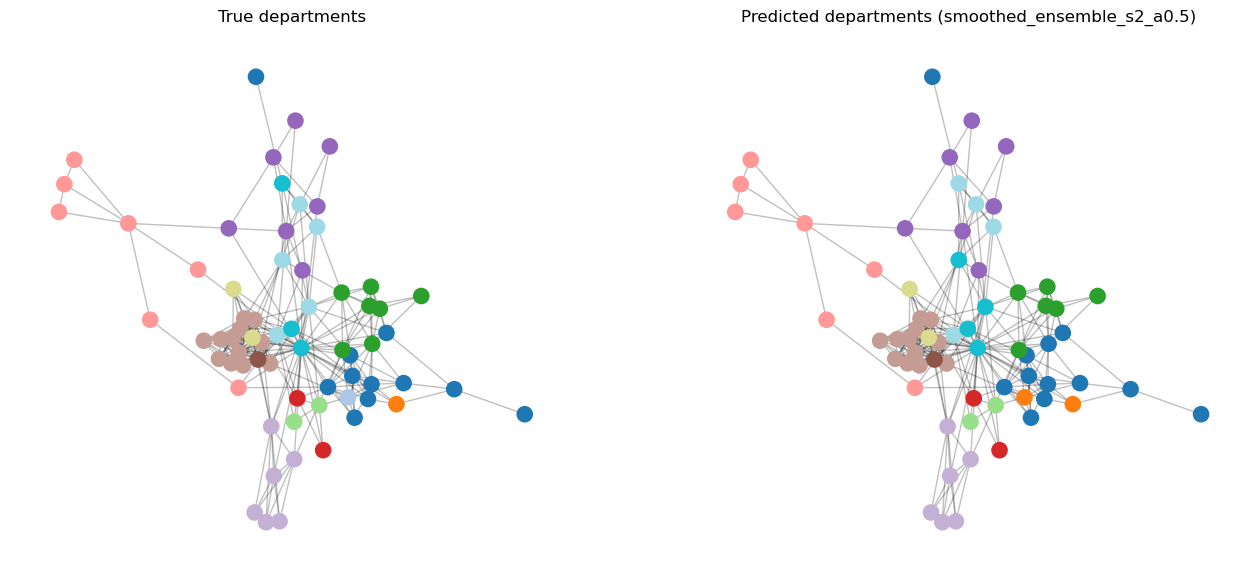

In [181]:
predictions = best_run["predictions"]
idx_to_node_id = {idx: node_id for node_id, idx in node_id_to_idx.items()}

test_indices = test_mask.nonzero(as_tuple=True)[0].tolist()
random.seed(42)
center_indices = random.sample(test_indices, min(12, len(test_indices)))
center_nodes = [idx_to_node_id[idx] for idx in center_indices]

visual_nodes = set(center_nodes)
for node in center_nodes:
    visual_nodes.update(list(G.predecessors(node))[:4])
    visual_nodes.update(list(G.successors(node))[:4])

visual_nodes = list(visual_nodes)[:90]
visual_subgraph = G.subgraph(visual_nodes).to_undirected().copy()
pos = nx.spring_layout(visual_subgraph, seed=42)

true_colors = [
    class_to_idx.get(node_to_label.get(node, -1), -1)
    for node in visual_subgraph.nodes()
]
pred_colors = [
    predictions[node_id_to_idx[node]].item()
    if node_id_to_idx[node] in valid_indices.tolist()
    else -1
    for node in visual_subgraph.nodes()
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, colors, title in zip(
    axes,
    [true_colors, pred_colors],
    ["True departments", f"Predicted departments ({best_run.get('final_method', best_run['model'])})"],
):
    nx.draw_networkx_nodes(
        visual_subgraph,
        pos,
        node_size=120,
        node_color=colors,
        cmap=plt.cm.tab20,
        ax=ax,
    )
    nx.draw_networkx_edges(
        visual_subgraph,
        pos,
        alpha=0.25,
        ax=ax,
    )
    ax.set_title(title)
    ax.axis("off")

plt.show()
